In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
dataset = pd.read_csv("/content/multiple regression.csv", encoding='latin-1')
dataset.head(3)

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2018.06.25,25-Jun-2018,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,...,White shark,"R. Collier, GSAF",2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.25,2018.06.25,6303.0,NaN,NaN
1,2018.06.18,18-Jun-2018,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.18,2018.06.18,6302.0,NaN,NaN
2,2018.06.09,09-Jun-2018,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.09,2018.06.09,6301.0,NaN,NaN


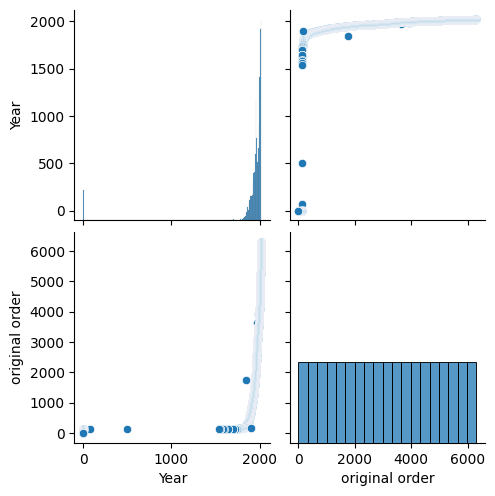

In [153]:
sns.pairplot(data=dataset)
plt.show()

In [152]:
dataset.isnull().sum()

,0
Case Number,17021
Date,19421
Year,19423
Type,19425
Country,19471
Area,19876
Location,19961
Activity,19965
Name,19631
Sex,19986


In [154]:
x = dataset.iloc[:,:-1]
y = dataset["Year"]

In [155]:
from sklearn.model_selection import train_test_split

In [156]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [157]:
from sklearn.tree import DecisionTreeRegressor,plot_tree

In [160]:
# Identify and drop non-numeric columns from x_train and x_test
non_numeric_cols = x_train.select_dtypes(exclude=['number']).columns
x_train_numeric = x_train.drop(columns=non_numeric_cols)
x_test_numeric = x_test.drop(columns=non_numeric_cols)

# Handle missing values in y_train by filling with the mean
y_train_filled = y_train.fillna(y_train.mean())

# Handle missing values in x_train_numeric and x_test_numeric by filling with the mean
x_train_numeric_filled = x_train_numeric.fillna(x_train_numeric.mean())
x_test_numeric_filled = x_test_numeric.fillna(x_test_numeric.mean())

dt = DecisionTreeRegressor()
dt.fit(x_train_numeric_filled,y_train_filled)

DecisionTreeRegressor()

In [162]:
# Handle missing values in y_test by filling with the mean of y_train (as done for y_train)
y_test_filled = y_test.fillna(y_train.mean())

dt.score(x_test_numeric_filled,y_test_filled)*100

99.29295151512372

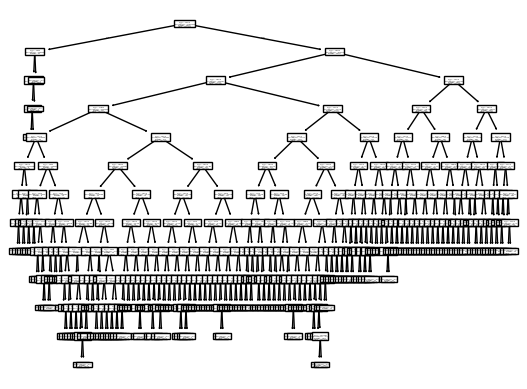

In [163]:
plot_tree(dt)
plt.show()